## 1. Imports and the experiment configuration

In [1]:
import json, os, glob, re, copy
from dataclasses import dataclass, asdict
from typing import Optional
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# unit definitions
nm, ps, fs = 1e-9, 1e-12, 1e-15


In [3]:
# Experimental configuration

# All time quantities are in ps
# All space quantitites are in nm

CFG = dict(
    
    # Experimental parameters
    lambda_pump_nm      = 400.0, # pump wavelength 
    lambda_probe_nm     = 514.0, # probe wavelength 
    pump_fluence_J_m2   = 1.0,   # pump fluence --- scales absolute amplitude of W(z)
    pulse_fwhm_ps       = 0.20,  # temporal width of Gaussian used in temperature_shapes --- laser pulse duration
    
    # Time axis
    t_min_ps            = -10.0, # -ve to capture the baseline before pump arrives
    t_max_ps            = 400.0, # length of simulation
    dt_out_ps           = 0.05,  # o/p time axis dumping
    
    # Spatial grid
    dz_nm               = 1.0,   # z step
    substrate_model_nm  = 4000.0,# Size of the substrate for simulation --- must be > v_sound * t_max
    sponge_nm           = 800.0, # Absorbing layer appended after the substrate chunk to gradually damping the wave to zero
    
    # Safety factor
    cfl                 = 0.40,  # Stability of leapfrog: actual dt = cfl * dz/v_max (must be < 1)
    
    
    # Thermal decay time
    tau_th_ps           = 500.0, # Time for lattice temperature to decay --- fit to experiment or estimated from d²/(thermal diffusivity)
    
    # Physics --- individual contributions to dR/R
    include_strain      = True,  # photoelastic contribution from bulk strain wave
    include_lattice_T   = True,  # thermo-optic contribution from lattice heating
    include_electron_T  = True,  # thermo-optic contribution from electron heating (metals only)
    include_displacement= True,  # contribution from interfaces moving (surface + internal)
)


## 2. `Material` and `Layer` — the data containers

In [4]:
# How this cell works: 
#                         User specifies Layer objects
#                                     ↓
#        build_sample() resolves every value (from file, fill=, LITERATURE, or override)
#                                     ↓
#                     as_material() converts Layer → Material
#                                     ↓
#                       Solver uses Material objects only


# Defining material properties
# Works as a runtime container --- holds fully resolved validated values
# Used by the solver
@dataclass
class Material:
    """Everything the model needs about one layer's substance."""
    
    name: str
    rho: float             # density : kg/m^3
    v: float               # longitudinal sound velocity : m/s
    Cp: float              # isobaric heat capacity: J/kgK
    alpha_lin: float       # linear thermal expansion : 1/K
    B_bulk: float          # bulk modulus : Pa
    n_pump: complex        # n + ik at the pump wavelength : complex refractive index : n_tilde
    n_probe: complex       # n + ik at the probe wavelength : complex refractive index : n_tilde
    dn_deta: complex       # photoelastic  d(n+ik)/d(strain) : dimensionality less quantity
    dn_dT: complex         # thermo-optic  d(n+ik)/dT_lattice : 1/K
    dn_dTe: complex = 0j   # electronic    d(n+ik)/dT_electron : 1/K
    Ce: float = 0.0        # electron heat capacity : J/m^3K
    tau_ep_ps: float = 1.0 # electron-phonon coupling time : ps

    @property
    def Z(self):    return self.rho * self.v            # acoustic impedance : Z=rho*v
    @property
    def C11(self):  return self.rho * self.v ** 2       # longitudinal modulus : C11=rho*v^2
    @property
    def Bth(self):  return 3.0 * self.B_bulk * self.alpha_lin   # Bth=3*B*alpha : Pa/K


# Defining layers
# Acts as an input container --- works even when the user don't know all the values
@dataclass
class Layer:
    """One physical layer of the stack. d_nm=None means semi-infinite."""
    
    material: str
    d_nm: Optional[float]     # layer thickness
    rho: float = 0.0          # layer density
    v: float = 0.0            # sound velocity in the layer
    Cp: float = 700.0         # isobaric heat capacity of the layer
    alpha_lin: float = 0.0    # linear thermal expansion of the layer 
    B_bulk: float = 0.0       # bulk modulus of the layer 
    n_pump: complex = 1 + 0j  # complex refractive index at pump wavelength in the layer
    n_probe: complex = 1 + 0j # complex refractive index at probe wavelength in the layer
    dn_deta: complex = 0j     # dn/deta
    dn_dT: complex = 0j       # dn/dT
    dn_dTe: complex = 0j      # dn/dTe
    Ce: float = 0.0           # electronic heat capacity in the layer
    tau_ep_ps: float = 1.0    # e-phonon coupling time in the layer

    def as_material(self, key):
        return Material(key, self.rho, self.v, self.Cp, self.alpha_lin,
                        self.B_bulk, self.n_pump, self.n_probe, self.dn_deta,
                        self.dn_dT, self.dn_dTe, self.Ce, self.tau_ep_ps)


def make_sample(layers):
    """[Layer, ...] -> (stack, materials), giving every layer a unique key."""
    if sum(l.d_nm is None for l in layers) != 1 or layers[-1].d_nm is not None:
        raise ValueError("exactly one layer must have d_nm=None, and it must "
                         "be the last one (the substrate)")
    stack, materials, seen = [], {}, {}
    for l in layers:
        n = seen.get(l.material, 0)
        seen[l.material] = n + 1
        key = l.material if n == 0 else f"{l.material}#{n + 1}"
        materials[key] = l.as_material(key)
        stack.append((key, l.d_nm))
    return stack, materials




# Example: 
# Say, the stack looks like this:
# [SiO2(20nm), Ti(5nm), SiO2(50nm), Si(None)]
# seen tracks how many times a material has been encountered so far
#  Layer 1 — SiO2:
#    seen.get("SiO2", 0) = 0      → n=0, first time seen
#    seen["SiO2"] = 1
#    key = "SiO2"                 (no suffix, first occurrence)
#
#  Layer 2 — Ti:
#    seen.get("Ti", 0) = 0        → n=0, first time seen
#    seen["Ti"] = 1
#    key = "Ti"
#
#  Layer 3 — SiO2:
#    seen.get("SiO2", 0) = 1      → n=1, seen before!
#    seen["SiO2"] = 2
#    key = "SiO2#2"               (suffix added)
#
#  Layer 4 — Si:
#    seen.get("Si", 0) = 0        → n=0, first time seen
#    seen["Si"] = 1
#    key = "Si"
#
# So the resulting material dictionary has four distinct keys:
# {
#    "SiO2":   Material(..., d=20nm),
#    "Ti":     Material(...),
#    "SiO2#2": Material(..., d=50nm),
#    "Si":     Material(...),
# }
#
# And the stack is:
# [("SiO2", 20.0), ("Ti", 5.0), ("SiO2#2", 50.0), ("Si", None)]





## 3. `MaterialLibrary` — reading material folder

In [5]:
# Using a generic Exception, leaves no way to distinguish 
# "material data is missing" from "file not found" or "numpy shape mismatch" or any other error 
# We have to either catch everything or parse the error string, both of which are bad practice.
# pass means "inherit everything from Exception, add nothing"
# In python, every Exception must be a class. 
class MissingMaterialData(Exception):
    pass

# Literature values to fall back to
# Si3N4 and SiO2 are insulators; no free e-s 
# Ti is the most used transducer material so the data is complete
LITERATURE = {
    "Si3N4": dict(rho=3200.,  v=10300., Cp=700., alpha_lin=3.3e-6,  B_bulk=250e9, k=0.0, dn_deta=-1.0 + 0j,    dn_dT=2.5e-5 + 0j),
    "SiO2":  dict(rho=2200.,  v=5970.,  Cp=740., alpha_lin=0.5e-6,  B_bulk=37e9,  k=0.0, dn_deta=-0.4 + 0j,    dn_dT=1.0e-5 + 0j),
    "Ti":    dict(rho=4506.,  v=6070.,  Cp=523., alpha_lin=8.6e-6,  B_bulk=110e9,        dn_deta=3.0 + 1.0j,   dn_dT=1.0e-4 + 5e-5j, dn_dTe=6.0e-6 + 6.0e-6j, Ce=9.6e4, tau_ep_ps=0.6),
    "Si":    dict(rho=2329.,  v=8433.,  Cp=700., alpha_lin=2.6e-6,  B_bulk=98e9,         dn_deta=-12.0 + 0.5j, dn_dT=2.0e-4 + 1e-5j),
    "Al":    dict(rho=2700.,  v=6420.,  Cp=897., alpha_lin=23.1e-6, B_bulk=76e9,                                                     dn_dTe=1e-5 + 1e-5j,     Ce=2.1e4, tau_ep_ps=0.5),
    "Au":    dict(rho=19300., v=3240.,  Cp=129., alpha_lin=14.2e-6, B_bulk=180e9,                                                    dn_dTe=1e-5 + 1e-5j,     Ce=2.1e4, tau_ep_ps=1.0),
}


# Lists of property names used in build_samples to loop over systematically --- keys
# Layer quantities
_CORE = ["rho", "v", "Cp", "alpha_lin", "B_bulk", "dn_deta", "dn_dT"]
# Electronic quantities
_ELEC = ["dn_dTe", "Ce", "tau_ep_ps"]

# byte order mark --- check for encoding of the file
_BOMS = ((b"\xff\xfe\x00\x00", "utf-32-le"), (b"\x00\x00\xfe\xff", "utf-32-be"),
         (b"\xff\xfe",         "utf-16-le"), (b"\xfe\xff",         "utf-16-be"),
         (b"\xef\xbb\xbf",     "utf-8-sig"))


# column-1 unit -> nm.  eV is handled separately because it inverts the axis.
# converts everything to nm
_UNIT_TO_NM = {"nm": 1.0, "um": 1e3, "micron": 1e3, "µm": 1e3, "m": 1e9,
               "a": 0.1, "ang": 0.1, "angstrom": 0.1}
# ev conversion
_HC_EV_NM = 1239.841984          # h c / e, in eV nm


def to_nm(x, unit):
    """Convert a wavelength/energy column to nm."""
    u = unit.strip().lower()
    if u in ("ev", "e"):
        return _HC_EV_NM / np.asarray(x, float)
    if u not in _UNIT_TO_NM:
        raise ValueError(f"unknown unit {unit!r}; use nm, um, A, m or eV")
    return np.asarray(x, float) * _UNIT_TO_NM[u]


def guess_unit(x):
    """(unit, why) for column 1 of a dispersion table. Never silent."""
    lo, hi = float(np.min(x)), float(np.max(x))
    if hi < 100.0:
        return "um", ("values < 100 -- micrometres assumed. If this table is in "
                      "eV, pass units={'<name>': 'eV'}")
    if lo > 1500.0:
        return "A", ("values > 1500 -- angstroms assumed. If it really is nm, "
                     "pass units={'<name>': 'nm'}")
    return "nm", ""


def read_text_lines(path):
    """Read a text file of unknown encoding -> (lines, encoding_name).

    Handles the UTF-16 / UTF-8-BOM files Windows editors and some instrument
    software produce, and falls back to latin-1 rather than raising, since a
    stray degree sign in a comment should not stop a numeric table loading.
    """
    raw = open(path, "rb").read()
    for bom, enc in _BOMS:
        if raw.startswith(bom):
            text = raw[len(bom):].decode(enc, errors="replace")
            return text.splitlines(), enc
    if raw.count(b"\x00") > len(raw) // 4:          # BOM-less UTF-16
        enc = "utf-16-le" if raw[1:2] == b"\x00" else "utf-16-be"
        return raw.decode(enc, errors="replace").splitlines(), enc + " (no BOM)"
    for enc in ("utf-8", "cp1250", "latin-1"):
        try:
            return raw.decode(enc).splitlines(), enc
        except UnicodeDecodeError:
            continue
    return raw.decode("latin-1", errors="replace").splitlines(), "latin-1 (lossy)"


def _numbers(line):
    """One data row -> list of floats, or None for a comment / header line."""
    line = line.lstrip("\ufeff").split("#")[0].split("%")[0].strip()
    if not line:
        return None
    if ";" in line and "," in line and "." not in line:
        line = line.replace(",", ".")           # Czech-locale decimal comma
    parts = [p for p in re.split(r"[;,\s]+", line) if p]
    try:
        return [float(p) for p in parts]
    except ValueError:
        return None


def _parse_val(s):
    s = s.strip()
    try:
        return float(s)
    except ValueError:
        return complex(s.replace("i", "j"))


class MaterialLibrary:
    """Reads <folder>/<Name>.txt dispersion tables and the constants files."""

    def __init__(self, folder, props_file="properties.txt", units=None,
                 verbose=True):
        self.folder = os.path.normpath(folder)
        self.optical, self.props, self.skipped, self.encodings = {}, {}, {}, {}
        self.units = {}
        units = units or {}

        for p in sorted(glob.glob(os.path.join(self.folder, "*.txt"))):
            if os.path.basename(p) == props_file:
                continue
            name = os.path.splitext(os.path.basename(p))[0]
            try:
                lines, enc = read_text_lines(p)
                rows = [r for r in (_numbers(l) for l in lines) if r]
                if not rows:
                    self.skipped[name] = "no numeric rows found"
                    continue
                width = max(len(r) for r in rows)
                if width < 2:
                    self.skipped[name] = f"only {width} column(s); need >= 2"
                    continue
                a = np.array([r[:3] for r in rows if len(r) == width], float)
                if len(a) < 2:
                    self.skipped[name] = "fewer than 2 consistent data rows"
                    continue

                # --- column 1 units -------------------------------------
                declared = next((m.group(1) for l in lines
                                 for m in [re.match(r"\s*[#%]\s*unit\s*[:=]\s*"
                                                    r"(\S+)", l, re.I)] if m), None)
                unit = units.get(name) or declared
                why = "" if unit else None
                if unit is None:
                    unit, why = guess_unit(a[:, 0])
                raw_lo, raw_hi = a[0, 0], a[-1, 0]
                a[:, 0] = to_nm(a[:, 0], unit)
                a = a[np.argsort(a[:, 0])]
                self.units[name] = (unit, raw_lo, raw_hi, why)
            except Exception as e:
                self.skipped[name] = f"{type(e).__name__}: {e}"
                continue
            self.encodings[name] = enc
            self.optical[name] = dict(lam=a[:, 0], n=a[:, 1],
                                      k=(a[:, 2] if a.shape[1] > 2 else None),
                                      path=p)

        for p in ([os.path.join(self.folder, props_file)]
                  + sorted(glob.glob(os.path.join(self.folder, "*.prop")))):
            if not os.path.exists(p):
                continue
            per_file = p.endswith(".prop")
            fname = os.path.splitext(os.path.basename(p))[0]
            lines, _ = read_text_lines(p)
            for line in lines:
                line = line.lstrip("\ufeff").split("#")[0].strip()
                if "=" not in line:
                    continue
                key, _, val = line.partition("=")
                if per_file:
                    mat, prop = fname, key.strip()
                else:
                    mat, _, prop = key.strip().partition(".")
                    prop = prop.strip()
                try:
                    self.props.setdefault(mat, {})[prop] = _parse_val(val)
                except ValueError:
                    print(f"!! {os.path.basename(p)}: could not parse "
                          f"{line!r}, skipped")

        if verbose:
            for name in sorted(self.optical):
                d = self.optical[name]
                unit, raw_lo, raw_hi, why = self.units[name]
                kcol = "n+k" if d["k"] is not None else "n only"
                src = (f"col1 in {unit}" if unit != "nm" else "col1 in nm")
                print(f"  {name:<10} {len(d['lam']):>3} rows  "
                      f"{d['lam'][0]:>7.1f}-{d['lam'][-1]:<8.1f} nm  {kcol:<7} "
                      f"{src:<12} [{self.encodings[name]}]")
                if why:
                    print(f"  {'':<10} ^^ {raw_lo:g}-{raw_hi:g} in the file; "
                          f"{why.replace('<name>', name)}")
            for name, why in sorted(self.skipped.items()):
                print(f"  {name:<10} SKIPPED -- {why}")
            if not self.optical:
                print(f"  no usable dispersion files found in {self.folder}")

    def nk(self, name, lam_nm):
        """(n, k, note) at one wavelength; k is None when not tabulated."""
        d = self.optical[name]
        lam = d["lam"]
        if lam_nm < lam[0] - 1e-9 or lam_nm > lam[-1] + 1e-9:
            raise MissingMaterialData(
                f"{name}: {lam_nm:g} nm is outside the tabulated range "
                f"{lam[0]:g}-{lam[-1]:g} nm in {d['path']}. Extend the file; "
                f"the loader will not extrapolate.")
        j = int(np.clip(np.searchsorted(lam, lam_nm) - 1, 0, len(lam) - 2))
        note = f"interp {lam[j]:g}-{lam[j+1]:g} nm"
        n = float(np.interp(lam_nm, lam, d["n"]))
        k = float(np.interp(lam_nm, lam, d["k"])) if d["k"] is not None else None
        return n, k, note

    def __repr__(self):
        return (f"<MaterialLibrary {self.folder!r}: optical="
                f"{sorted(self.optical)}, props={sorted(self.props)}"
                + (f", skipped={sorted(self.skipped)}" if self.skipped else "")
                + ">")


## 4. `build_sample` — layers in, model out, guesses flagged

In [6]:
def pe_to_dn_deta(pe, n):
    """Photoelastic constant (indicatrix convention) -> dn/d(strain).

    The lab pipeline (get_simul_wl_signal6) uses  d(1/n^2) = p * eta,  so
        dn/d(eta) = -p * n^3 / 2
    n is complex and wavelength dependent, so dn_deta is too -- this must be
    evaluated at the probe wavelength, not once for all time.
    """
    return -np.asarray(pe) * np.asarray(n, complex) ** 3 / 2.0


def build_sample(layers, lib, cfg=None, fill=None, use_literature=True,
                 verbose=True):
    """[("Si3N4", 20.0), ..., ("Si", None)] -> (stack, materials).

    Optional third tuple element: per-layer overrides, so the same material can
    appear twice with different numbers.

    Resolution order for every quantity:
        per-layer override  ->  material files  ->  fill=  ->  LITERATURE

    use_literature=True (default) lets the last step run so the model builds,
    but every value taken that way is recorded as a placeholder, reported in a
    banner, marked with * in the summary table, and carried on the Material
    objects as `._placeholder` so it reaches the saved metadata.
    Set use_literature=False to raise instead.
    """
    cfg = dict(CFG, **(cfg or {}))
    fill = fill or {}
    lam_pu, lam_pr = cfg["lambda_pump_nm"], cfg["lambda_probe_nm"]
    built, prov, missing, placeholders = [], [], [], []

    for i, spec in enumerate(layers):
        name, d = spec[0], spec[1]
        over = dict(spec[2]) if len(spec) > 2 else {}
        f = dict(fill.get(name, {}))
        f.update(fill.get(i, {}))
        lit = LITERATURE.get(name, {})
        tag = f"{i}:{name}"
        ph_here, over_src = set(), {}

        def take(key, optional=False, lit_key=None):
            lk = lit_key or key
            if key in over:
                prov.append((tag, key, over[key],
                             over_src.get(key, "per-layer override")))
                return over[key]
            if key in lib.props.get(name, {}):
                prov.append((tag, key, lib.props[name][key],
                             f"{lib.folder}/{name}"))
                return lib.props[name][key]
            if key in f:
                prov.append((tag, key, f[key], "fill= (you supplied)"))
                return f[key]
            if use_literature and lk in lit:
                prov.append((tag, key, lit[lk], "*** LITERATURE PLACEHOLDER"))
                placeholders.append((tag, key, lit[lk]))
                ph_here.add(key)
                return lit[lk]
            if not optional:
                missing.append((tag, key, lit.get(lk)))
            return None

        nk = {}
        # a layer may name its own dispersion table, so two layers of the same
        # material can use different measured n,k
        optkey = over.pop("nfile", name)
        pe = over.pop("pe", None)
        if optkey not in lib.optical and not ({"n_pump", "n_probe"} <= set(over)):
            missing.append((tag, "optical file",
                            f"no {optkey}.txt in {lib.folder}"))
        else:
            for which, lam in (("pump", lam_pu), ("probe", lam_pr)):
                if f"n_{which}" in over:
                    nk[which] = complex(over[f"n_{which}"])
                    prov.append((tag, f"n_{which}", nk[which], "per-layer override"))
                    continue
                n, k, note = lib.nk(optkey, lam)
                if k is None:
                    kk = take(f"k_{which}", optional=True, lit_key="k")
                    if kk is None:
                        kk = f.get("k")
                        if kk is None:
                            missing.append((tag, f"k_{which}", lit.get("k")))
                            kk = 0.0
                        else:
                            prov.append((tag, f"k_{which}", kk,
                                         "fill= (you supplied)"))
                    nk[which] = complex(n, kk)
                else:
                    nk[which] = complex(n, k)
                prov.append((tag, f"n_{which}", nk[which],
                             f"{optkey}.txt, {note}"))

        if pe is not None and "dn_deta" not in over:
            over["dn_deta"] = pe_to_dn_deta(pe, nk["probe"])
            over_src["dn_deta"] = f"conf peCoef={pe:g}, via -p n^3/2"
        vals = {key: take(key) for key in _CORE}
        for key in _ELEC:
            vals[key] = take(key, optional=True)
        if vals["Ce"] is None:
            prov.append((tag, "Ce", 0.0,
                         "not on file -> assumed non-metallic, no e- channel"))
        vals["dn_dTe"] = vals["dn_dTe"] or 0j
        vals["Ce"] = vals["Ce"] or 0.0
        vals["tau_ep_ps"] = vals["tau_ep_ps"] or 1.0
        built.append((name, d, nk, vals, ph_here))

    if missing:
        raise MissingMaterialData(_missing_report(missing, use_literature))

    out = [Layer(name, d, rho=float(v["rho"]), v=float(v["v"]),
                 Cp=float(v["Cp"]), alpha_lin=float(v["alpha_lin"]),
                 B_bulk=float(v["B_bulk"]), n_pump=nk["pump"],
                 n_probe=nk["probe"], dn_deta=complex(v["dn_deta"]),
                 dn_dT=complex(v["dn_dT"]), dn_dTe=complex(v["dn_dTe"]),
                 Ce=float(v["Ce"]), tau_ep_ps=float(v["tau_ep_ps"]))
           for name, d, nk, v, _ in built]
    stack, materials = make_sample(out)
    for (key, _), (_, _, _, _, ph) in zip(stack, built):
        materials[key]._placeholder = set(ph)

    if cfg.get("include_electron_T", True):
        g = build_grid(stack, materials, cfg)
        W, _ = absorption_profile(stack, materials, g, cfg)
        j = int(np.argmax([(W[g["idx_half"] == q].max()
                            if (g["idx_half"] == q).any() else 0.0)
                           for q in range(len(g["names"]))]))
        if materials[g["names"][j]].Ce == 0.0:
            print(f"!! {g['names'][j]} has the highest absorbed energy density"
                  f" but Ce = 0,"
                  f" so the electron channel is silent.\n"
                  f"   Give it Ce and tau_ep_ps, or set include_electron_T"
                  f"=False.\n")

    if verbose:
        from_file = [q for q in prov if ".txt," in q[3] or
                     q[3].startswith(lib.folder)]
        assumed = [q for q in prov if q not in from_file]
        print(f"probe {lam_pr:g} nm, pump {lam_pu:g} nm -- {len(from_file)} "
              f"values from {lib.folder}/, {len(assumed)} supplied or assumed")
        rows = prov if verbose == 2 else assumed
        if rows:
            if verbose != 2:
                print("\nnot read from the material files:")
            print(f"\n{'layer':<10}{'quantity':<12}{'value':>20}   source")
            print("-" * 76)
            for tag, key, val, src in rows:
                v_ = (f"{val:.6g}" if isinstance(val, float) else
                      f"{val.real:.5g}{val.imag:+.5g}j"
                      if isinstance(val, complex) else str(val))
                print(f"{tag:<10}{key:<12}{v_:>20}   {src}")
        print()
        placeholder_banner(placeholders)
        sample_table(stack, materials, cfg)
    return stack, materials


def placeholder_banner(placeholders):
    """Loud, compact summary of what is a guess rather than a measurement."""
    if not placeholders:
        print("no literature placeholders: every value came from the files, "
              "fill= or an override\n")
        return
    by_layer = {}
    for tag, key, _ in placeholders:
        by_layer.setdefault(tag, []).append(key)
    bar = "!" * 76
    print(bar)
    print(f"!! {len(placeholders)} values are LITERATURE PLACEHOLDERS, "
          f"not measurements:")
    for tag, keys in by_layer.items():
        print(f"!!   {tag:<10} {' '.join(keys)}")
    touched = {k for _, k, _ in placeholders}
    if touched & {"v", "rho"}:
        print("!! v or rho is a guess -> echo periods (2d/v) and Brillouin "
              "frequencies are guesses too.")
    if touched & {"dn_deta", "dn_dT", "dn_dTe"}:
        print("!! a coupling coefficient is a guess -> the dR/R amplitude is "
              "not quantitative.")
    if touched & {"k", "k_pump", "k_probe"}:
        print("!! k is a guess -> the absorption profile, and therefore the "
              "strain source, is uncertain.")
    print("!! Pass use_literature=False to refuse to build on placeholders.")
    print(bar + "\n")


def _missing_report(missing, use_literature=True):
    by_layer = {}
    for tag, key, lit in missing:
        by_layer.setdefault(tag, []).append((key, lit))
    lines = ["", "Missing material data -- nothing was substituted.", ""]
    for tag, items in by_layer.items():
        lines.append(f"  layer {tag}:")
        for key, lit in items:
            if key == "optical file":
                lines.append(f"      {key:<14} {lit}")
                continue
            s = ("no literature value on file" if lit is None
                 else f"literature placeholder: {lit!r}")
            lines.append(f"      {key:<14} {s}")
    if not use_literature:
        lines += ["", "You passed use_literature=False. Either drop that, add "
                  "the values to the", "material files, or supply them "
                  "explicitly by pasting:", "", "fill = {"]
    else:
        lines += ["", "These have no literature entry either, so you must "
                  "supply them:", "", "fill = {"]
    per_mat = {}
    for tag, items in by_layer.items():
        per_mat.setdefault(tag.split(":", 1)[1], {}).update(dict(items))
    for name, items in per_mat.items():
        items = {k: v for k, v in items.items() if k != "optical file"}
        body = ", ".join(f"{k}={v!r}" for k, v in items.items() if v is not None)
        todo = [k for k, v in items.items() if v is None]
        if todo:
            body += (", " if body else "") + ", ".join(f"{k}=?" for k in todo)
        lines.append(f'    "{name}": dict({body}),')
    lines += ["}", "", "then  build_sample(SAMPLE, LIB, CFG, fill=fill)."]
    if any(k == "optical file" for items in by_layer.values()
           for k, _ in items):
        lines += ["", "A missing dispersion file cannot be patched through "
                  "fill=; add the .txt to the",
                  "materials folder, or give n_pump and n_probe as a per-layer "
                  "override:",
                  '    ("HfO2", 50.0, dict(n_pump=2.1+0j, n_probe=2.08+0j))']
    return "\n".join(lines)


def sample_table(stack, materials, cfg=None):
    """What the model is about to use.  * marks a literature placeholder."""
    cfg = dict(CFG, **(cfg or {}))
    lam_p = cfg["lambda_probe_nm"]
    print(f"{'layer':<12}{'d (nm)':>8}{'n_probe':>17}{'rho':>9}{'v (m/s)':>10}"
          f"{'Z (MRayl)':>11}{'2d/v (ps)':>11}{'f_B (GHz)':>11}")
    for key, d in stack:
        m = materials[key]
        ph = getattr(m, "_placeholder", set())
        rt = 2 * d * nm / m.v / ps if d else float("nan")
        fB = 2 * m.n_probe.real * m.v / (lam_p * nm) / 1e9
        ds = "inf" if d is None else f"{d:g}"
        npr = f"{m.n_probe.real:.4f}{m.n_probe.imag:+.4f}j"
        rho_s = f"{m.rho:.0f}" + ("*" if "rho" in ph else "")
        v_s = f"{m.v:.0f}" + ("*" if "v" in ph else "")
        print(f"{key:<12}{ds:>8}{npr:>17}{rho_s:>9}{v_s:>10}"
              f"{m.Z/1e6:>11.2f}{rt:>11.2f}{fB:>11.1f}")
    if any(getattr(materials[k], "_placeholder", set()) for k, _ in stack):
        print("  * literature placeholder, not a measurement")


def placeholder_summary(materials):
    """{layer: sorted list of placeholder quantities} for a built sample."""
    return {k: sorted(v) for k, m in materials.items()
            for v in [getattr(m, "_placeholder", set())] if v}


## 5. The spatial grid (interfaces snapped to cell boundaries)

In [7]:
def build_grid(stack, materials, cfg):
    dz = cfg["dz_nm"] * nm
    finite = [(n, t) for n, t in stack if t is not None]
    d_stack = sum(t for _, t in finite) * nm
    z_end = d_stack + cfg["substrate_model_nm"] * nm + cfg["sponge_nm"] * nm
    N = int(round(z_end / dz))
    z_node = np.arange(N + 1) * dz
    z_half = (np.arange(N) + 0.5) * dz

    # Interfaces must sit on cell boundaries. prop_map assigns whole cells to
    # layers, so if tmm used the exact thicknesses while the material map used
    # snapped ones, the field and n(z) would disagree and the absorbed energy
    # would not converge. Snap once here and let everything use the same stack.
    edges, acc = [0.0], 0.0
    for _, t in finite:
        acc += t * nm
        edges.append(round(acc / dz) * dz)
    d_snap = [max(edges[j + 1] - edges[j], dz) for j in range(len(finite))]
    for j in range(1, len(edges)):
        edges[j] = edges[j - 1] + d_snap[j - 1]
    stack_snap = [(n, (None if t is None else d_snap[j] / nm))
                  for j, (n, t) in enumerate(stack)]
    edges.append(np.inf)
    names = [n for n, _ in stack]

    def idx_of(z):
        out = np.zeros(len(z), int)
        for j in range(len(names)):
            out[(z >= edges[j]) & (z < edges[j + 1])] = j
        return out

    return dict(dz=dz, N=N, z_node=z_node, z_half=z_half,
                idx_node=idx_of(z_node), idx_half=idx_of(z_half),
                names=names, edges=edges[:-1], d_stack=sum(d_snap),
                stack_snap=stack_snap, d_snap_nm=[t / nm for t in d_snap],
                z_sponge=sum(d_snap) + cfg["substrate_model_nm"] * nm)


def prop_map(grid, materials, which, attr):
    idx = grid["idx_" + which]
    vals = np.array([getattr(materials[n], attr) for n in grid["names"]])
    return vals[idx]


## 6. Optics: the transfer matrix

In [8]:
def tmm(stack, materials, lam_nm, which_n):
    k0 = 2 * np.pi / (lam_nm * nm)
    ns = [1.0 + 0j] + [complex(getattr(materials[n], which_n)) for n, _ in stack]
    ds = [0.0] + [(0.0 if t is None else t * nm) for _, t in stack]
    L = len(ns)
    M = np.eye(2, dtype=complex)
    Ds = []
    for j in range(L - 1):
        r = (ns[j] - ns[j + 1]) / (ns[j] + ns[j + 1])
        t = 2 * ns[j] / (ns[j] + ns[j + 1])
        Ds.append(np.array([[1, r], [r, 1]], complex) / t)
    for j in range(L - 1):
        if j > 0:
            d = k0 * ns[j] * ds[j]
            M = M @ np.array([[np.exp(-1j * d), 0], [0, np.exp(1j * d)]])
        M = M @ Ds[j]
    r_tot = M[1, 0] / M[0, 0]
    t_tot = 1.0 / M[0, 0]

    AB = [None] * L
    AB[L - 1] = np.array([t_tot, 0j])
    for j in range(L - 2, -1, -1):
        v = Ds[j] @ AB[j + 1]
        if j > 0:
            d = k0 * ns[j] * ds[j]
            v = np.array([np.exp(-1j * d), np.exp(1j * d)]) * v
        AB[j] = v
    return dict(k0=k0, ns=ns, r=r_tot, t=t_tot, AB=AB,
                z0=np.concatenate(([0.0], np.cumsum(ds[1:]))))


def optical_field(sol, grid, which):
    """Total complex field E(z) for unit incident amplitude."""
    z, idx = grid["z_" + which], grid["idx_" + which]
    E = np.zeros(len(z), complex)
    for j in range(len(grid["names"])):
        m = idx == j
        if not m.any():
            continue
        A, Bc = sol["AB"][j + 1]
        ph = sol["k0"] * sol["ns"][j + 1] * (z[m] - sol["z0"][j])
        E[m] = A * np.exp(1j * ph) + Bc * np.exp(-1j * ph)
    return E


def poynting(sol, grid, which):
    z, idx = grid["z_" + which], grid["idx_" + which]
    S = np.zeros(len(z))
    for j in range(len(grid["names"])):
        m = idx == j
        if not m.any():
            continue
        A, Bc = sol["AB"][j + 1]
        nj = sol["ns"][j + 1]
        ph = sol["k0"] * nj * (z[m] - sol["z0"][j])
        u, w = A * np.exp(1j * ph), Bc * np.exp(-1j * ph)
        S[m] = np.real(nj * (u + w) * np.conj(u - w))
    return S


## 7. Absorption, photoelastic kernel, interface-displacement response

In [9]:
def absorption_profile(stack, materials, grid, cfg):
    sol = tmm(grid["stack_snap"], materials, cfg["lambda_pump_nm"], "n_pump")
    E = optical_field(sol, grid, "half")
    n = prop_map(grid, materials, "half", "n_pump")
    W = (4 * np.pi * np.real(n) * np.imag(n) / (cfg["lambda_pump_nm"] * nm)) \
        * np.abs(E) ** 2 * cfg["pump_fluence_J_m2"]
    return W, sol


def sensitivity(stack, materials, grid, cfg):
    sol = tmm(grid["stack_snap"], materials, cfg["lambda_probe_nm"], "n_probe")
    E = optical_field(sol, grid, "half")
    n = prop_map(grid, materials, "half", "n_probe")
    pre = 2 * sol["k0"] * E ** 2 / sol["r"]
    f = {}
    for key, attr in (("eta", "dn_deta"), ("T", "dn_dT"), ("Te", "dn_dTe")):
        d = prop_map(grid, materials, "half", attr)
        f[key] = np.real(1j * n * d * pre)
        f[key][grid["z_half"] > grid["z_sponge"]] = 0.0
    return f, sol


def interface_sensitivity(stack, materials, grid, cfg, sol=None):
    """dR/R response to interfaces being displaced by the acoustic field.

    A displacement field u(z) does two things to the dielectric function. It
    strains the material, which is the photoelastic term already in
    sensitivity(). It also *moves* it, so at fixed lab coordinate z

        d(eps) = (d eps/d eta) eta(z)  -  u(z) d(eps)/dz

    The second piece is zero inside a homogeneous layer and a delta function at
    every interface, where eps jumps by d_eps_j. Feeding that through the same
    perturbative reflection integral gives a contribution linear in the
    interface displacements:

        dR/R|_disp = sum_j  f_u[j] * u(z_j),
        f_u[j] = -Re( i k0 d_eps_j E^2(z_j) / r )

    z_j = 0 is included: that is the free surface moving, the classic
    surface-displacement term. This is the same physics that
    get_simul_wl_signal6 puts in through `stack_change = strain * d_stack`.
    """
    if sol is None:
        sol = tmm(grid["stack_snap"], materials, cfg["lambda_probe_nm"], "n_probe")
    E_node = optical_field(sol, grid, "node")
    names = grid["names"]
    eps = [complex(materials[n].n_probe) ** 2 for n in names]

    idx, f_u, where = [], [], []
    for j, z_edge in enumerate(grid["edges"]):
        i_node = int(round(z_edge / grid["dz"]))
        if i_node >= len(E_node):
            continue
        eps_above = 1.0 + 0j if j == 0 else eps[j - 1]
        d_eps = eps[j] - eps_above
        if abs(d_eps) < 1e-12:
            continue
        idx.append(i_node)
        f_u.append(-np.real(1j * sol["k0"] * d_eps * E_node[i_node] ** 2
                            / sol["r"]))
        where.append(("surface" if j == 0 else f"{names[j-1]}|{names[j]}",
                      z_edge / nm))
    return np.array(idx, int), np.array(f_u), where


## 8. **The one cell** — build the sample from the conf file

In [10]:
def parse_conf(path):
    """Read a fs-sonar conf_file_*.txt -> (layers, materials_folder).

    Each layer block gives [Number] [Mater.] [thickn] [nFile ] [peCoef].
    A thickness of -1 means "rest of the stack", i.e. the substrate.
    """
    lines, _ = read_text_lines(path)
    folder, blocks, cur = None, [], {}
    for raw in lines:
        s = raw.strip()
        if not s or s.startswith("%"):
            continue
        m = re.match(r"\[([^\]]+)\]\s*(.*)$", s)
        if not m:
            if folder is None:
                folder = s                      # first bare line = material folder
            continue
        key, val = m.group(1).strip().lower(), m.group(2).strip()
        if key == "number" and cur:
            blocks.append(cur); cur = {}
        cur[key] = val
    if cur:
        blocks.append(cur)

    layers = []
    for b in blocks:
        d = float(b["thickn"])
        layers.append(dict(
            material=b["mater."],
            d_nm=(None if d < 0 else d),
            nfile=os.path.splitext(b["nfile"])[0],
            pe=float(b.get("pecoef", "nan")),
        ))
    return layers, folder


def sample_from_conf(path, lib, cfg=None, fill=None, verbose=True, **kw):
    """Build (stack, materials) straight from a conf file.

    Thicknesses, dispersion tables and photoelastic coefficients all come from
    the conf, so none of them can silently disagree with the simulation that
    conf described. Everything else (rho, v, Cp, alpha, B) is NOT in the conf
    and still has to come from the material files or LITERATURE.
    """
    layers, folder = parse_conf(path)
    if verbose:
        print(f"{os.path.basename(path)}")
        print(f"  materials folder in the conf: {folder}")
        if folder and not os.path.isdir(folder):
            print(f"  (not readable here -- using {lib.folder} instead)")
        print(f"\n  {'#':<3}{'material':<10}{'d (nm)':>9}{'peCoef':>9}   nFile")
        tot = 0.0
        for i, l in enumerate(layers, 1):
            tot += l["d_nm"] or 0.0
            ds = "substrate" if l["d_nm"] is None else f"{l['d_nm']:g}"
            print(f"  {i:<3}{l['material']:<10}{ds:>9}{l['pe']:>9.4g}   "
                  f"{l['nfile']}")
        print(f"  {'':<3}{'total finite':<10}{tot:>9.2f} nm")

    spec = [(l["material"], l["d_nm"],
             dict(nfile=l["nfile"], **({} if np.isnan(l["pe"])
                                       else dict(pe=l["pe"]))))
            for l in layers]
    return build_sample(spec, lib, cfg, fill=fill, verbose=verbose, **kw)




In [11]:
# ---------------------------------------------------------------------------
LIB = MaterialLibrary("L:/Compressed sensing/Matlab/ultrafast_Spectroscopy/fs_sonar/diffR_model/materials/")

CFG["lambda_pump_nm"]  = 514.0        # <- SET THESE to your actual arms
CFG["lambda_probe_nm"] = 514.0

CONF = "L:/Compressed sensing/Data/Fs_sonar/simulace_PM/251107_thick_SiO2_buffer/conf_file_v48_A.txt"
STACK, MATERIALS = sample_from_conf(CONF, LIB, CFG)


  BK7        2000 rows    360.0-840.0    nm  n+k     col1 in nm   [utf-8]
  BK7_krutoprisna 2000 rows    360.0-840.0    nm  n+k     col1 in nm   [utf-8]
  FusedSilica_substrate 101 rows    210.0-3710.0   nm  n+k     col1 in nm   [utf-8]
  S250917-1 Si3N4 n,k 2000 rows    400.0-960.0    nm  n+k     col1 in nm   [utf-8]
  S250917-1 SiO2 n,k 2000 rows    400.0-960.0    nm  n+k     col1 in nm   [utf-8]
  S250917-1 Ti n,k 151 rows    400.0-960.0    nm  n+k     col1 in nm   [utf-8]
  Si         151 rows    380.0-960.0    nm  n+k     col1 in nm   [utf-8]
  Si2xK      150 rows    380.0-960.0    nm  n+k     col1 in nm   [utf-8]
  Si3N4      101 rows    310.0-5504.0   nm  n only  col1 in nm   [utf-8]
  Si3N4_IBS_model 301 rows    380.1-980.0    nm  n+k     col1 in nm   [utf-8]
  Si3xK      150 rows    380.0-960.0    nm  n+k     col1 in nm   [utf-8]
  SiO2 [S171129-2] 2000 rows    380.0-960.0    nm  n+k     col1 in nm   [utf-8]
  Si_amorph   46 rows    103.3-2066.0   nm  n+k     col1 in nm   [utf

## 9. Temperature histories

In [12]:
def temperature_shapes(t, materials, grid, cfg, tau_ep_ps=None):
    dt = t[1] - t[0]
    sig = max(cfg["pulse_fwhm_ps"] * ps / 2.3548, 1e-3 * dt)
    half = max(int(np.ceil(4 * sig / dt)), 1)
    tk = np.arange(-half, half + 1) * dt
    g = np.exp(-0.5 * (tk / sig) ** 2)
    g /= g.sum()

    tau_ep = (tau_ep_ps if tau_ep_ps is not None else 1.0) * ps
    tau_th = cfg["tau_th_ps"] * ps
    step = (t >= 0).astype(float)
    tp = np.maximum(t, 0.0)
    raw_e = step * np.exp(-tp / tau_ep)
    raw_l = step * (1.0 - np.exp(-tp / tau_ep)) * np.exp(-tp / tau_th)
    pad = lambda y: np.concatenate((np.full(half, y[0]), y, np.full(half, y[-1])))
    conv = lambda y: np.convolve(pad(y), g, mode="valid")
    return conv(raw_e), conv(raw_l)


## 10. The thermoelastic solver

In [13]:
def run_model(stack=None, materials=None, cfg=None, verbose=True):
    stack = stack or STACK
    materials = materials or MATERIALS
    cfg = dict(CFG, **(cfg or {}))

    grid = build_grid(stack, materials, cfg)
    dz, N = grid["dz"], grid["N"]

    W, sol_pump = absorption_profile(stack, materials, grid, cfg)
    f, sol_probe = sensitivity(stack, materials, grid, cfg)
    idx_u, f_u, where_u = interface_sensitivity(stack, materials, grid, cfg,
                                                sol_probe)

    rho_n = prop_map(grid, materials, "node", "rho")
    C11_h = prop_map(grid, materials, "half", "C11")
    Bth_h = prop_map(grid, materials, "half", "Bth")
    Cp_h = prop_map(grid, materials, "half", "Cp")
    rho_h = prop_map(grid, materials, "half", "rho")
    Ce_h = prop_map(grid, materials, "half", "Ce")
    vmax = max(materials[n].v for n in grid["names"])

    dt_cfl = cfg["cfl"] * dz / vmax
    n_sub = max(1, int(np.ceil(cfg["dt_out_ps"] * ps / dt_cfl)))
    dt = cfg["dt_out_ps"] * ps / n_sub
    t_out = np.arange(cfg["t_min_ps"], cfg["t_max_ps"] + 1e-9,
                      cfg["dt_out_ps"]) * ps
    nt = len(t_out)
    t_fine = cfg["t_min_ps"] * ps + np.arange(nt * n_sub) * dt

    dT_l_prof = W / (rho_h * Cp_h)
    dT_e_prof = np.where(Ce_h > 0, W / np.where(Ce_h > 0, Ce_h, 1.0), 0.0)
    # The strain source is Bth * W/(rho Cp), an energy DENSITY. Picking the
    # layer with the largest TOTAL absorption would choose a semi-infinite
    # weakly-absorbing substrate over a thin metal film, which is backwards.
    per_layer = {n: (W[grid["idx_half"] == j].max()
                     if (grid["idx_half"] == j).any() else 0.0)
                 for j, n in enumerate(grid["names"])}
    transducer = max(per_layer, key=per_layer.get)
    ge_f, gl_f = temperature_shapes(t_fine, materials, grid, cfg,
                                    tau_ep_ps=materials[transducer].tau_ep_ps)
    ge, gl = ge_f[::n_sub], gl_f[::n_sub]

    src_h = Bth_h * dT_l_prof
    gam = np.zeros(N)
    m = grid["z_half"] > grid["z_sponge"]
    if m.any():
        x = (grid["z_half"][m] - grid["z_sponge"]) / (cfg["sponge_nm"] * nm)
        gam[m] = 2.0 * vmax / (cfg["sponge_nm"] * nm) * x ** 2
    gam_n = np.concatenate(([gam[0]], 0.5 * (gam[:-1] + gam[1:]), [gam[-1]]))
    damp = np.exp(-gam_n * dt)

    u = np.zeros(N + 1)
    v = np.zeros(N + 1)
    eta = np.zeros(N)
    drr_eta = np.zeros(nt)
    drr_u = np.zeros(nt)
    eta_snap = np.zeros((nt, N), dtype=np.float32) if cfg.get("save_strain") else None

    inv_rho_dz = 1.0 / (rho_n * dz)
    for it in range(nt):
        for s in range(n_sub):
            gl_now = gl_f[it * n_sub + s]
            sig = C11_h * eta - src_h * gl_now
            v[1:-1] += dt * inv_rho_dz[1:-1] * (sig[1:] - sig[:-1])
            v[0] += dt * inv_rho_dz[0] * (sig[0] - 0.0)
            v[-1] += dt * inv_rho_dz[-1] * (0.0 - sig[-1])
            v *= damp
            u += dt * v
            eta = (u[1:] - u[:-1]) / dz
        drr_eta[it] = eta @ f["eta"] * dz
        drr_u[it] = f_u @ u[idx_u]
        if eta_snap is not None:
            eta_snap[it] = eta

    drr_T = (f["T"] @ dT_l_prof) * dz * gl if cfg["include_lattice_T"] else 0 * gl
    drr_Te = (f["Te"] @ dT_e_prof) * dz * ge if cfg["include_electron_T"] else 0 * ge
    if not cfg["include_strain"]:
        drr_eta *= 0
    if not cfg.get("include_displacement", True):
        drr_u *= 0
    drr = drr_eta + drr_u + drr_T + drr_Te

    out = dict(t_ps=t_out / ps, drr=drr, drr_strain=drr_eta,
               drr_disp=drr_u, drr_acoustic=drr_eta + drr_u,
               drr_lattice=drr_T, drr_electron=drr_Te,
               f_u=f_u, idx_u=idx_u, where_u=where_u,
               z_nm=grid["z_half"] / nm, f_eta=f["eta"], f_T=f["T"],
               W=W, grid=grid, cfg=cfg, sol_pump=sol_pump, sol_probe=sol_probe,
               transducer=transducer, dt_ps=dt / ps, n_sub=n_sub, stack=stack,
               materials=materials, eta_zt=eta_snap)
    if verbose:
        R = abs(sol_pump["r"]) ** 2
        S_end = poynting(sol_pump, grid, "half")[-1]
        absorbed = np.sum(W) * dz / cfg["pump_fluence_J_m2"]
        print(f"  grid: N={N}  dz={dz/nm:g} nm  z_end={grid['z_node'][-1]/nm:g} nm")
        print(f"  time: dt={dt/ps:.4g} ps  substeps/output={n_sub}  nt={nt}")
        print(f"  pump  R={R:.4f}  flux_out={S_end:.4e}  absorbed={absorbed:.4f}"
              f"  sum={R+S_end+absorbed:.6f}")
        print(f"  probe R={abs(sol_probe['r'])**2:.4f}")
        print(f"  peak |dR/R| = {np.abs(drr).max():.3e}"
              f"   (photoelastic {np.abs(drr_eta).max():.2e}, "
              f"interface displacement {np.abs(drr_u).max():.2e})")
    return out


## 11. Saving and plotting

In [14]:
def save_result(res, basename=r"C:\Users\ramesh\Projects_TOPTEC\Generated_data\diffR_signal_thinfilm_model_custom", save_strain_map=False):
    """Write .npz + .csv. The meta string records which values were guesses."""
    meta = json.dumps(dict(cfg=dict(res["cfg"]),
                           stack=[[n, t] for n, t in res["stack"]],
                           transducer=res.get("transducer"),
                           R_probe=float(abs(res["sol_probe"]["r"]) ** 2),
                           R_pump=float(abs(res["sol_pump"]["r"]) ** 2),
                           placeholders=placeholder_summary(
                               res.get("materials", {}))))
    payload = dict(t_ps=res["t_ps"], drr=res["drr"],
                   drr_strain=res["drr_strain"], drr_disp=res["drr_disp"],
                   drr_lattice=res["drr_lattice"],
                   drr_electron=res["drr_electron"], z_nm=res["z_nm"],
                   f_eta=res["f_eta"], f_T=res["f_T"], W=res["W"], meta=meta)
    if save_strain_map and res.get("eta_zt") is not None:
        payload["eta_zt"] = res["eta_zt"][::20, ::2]
        payload["eta_z_nm"] = res["z_nm"][::2]
        payload["eta_t_ps"] = res["t_ps"][::20]
    np.savez_compressed(basename + ".npz", **payload)
    np.savetxt(basename + ".csv",
               np.column_stack([res["t_ps"], res["drr"], res["drr_strain"],
                                res["drr_disp"], res["drr_lattice"],
                                res["drr_electron"]]),
               delimiter=",", comments="",
               header="t_ps,dR_over_R,strain,displacement,lattice_T,"
                      "electron_T", fmt="%.8e")
    return basename + ".npz", basename + ".csv"


def plot_result(res, zoom_ps=60.0, savefig=None):
    t = res["t_ps"]
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(t, res["drr"] * 1e3, lw=1.0, color="k")
    ax[0].set_xlim(0, t.max()); ax[0].set_xlabel("delay (ps)")
    ax[0].set_ylabel(r"$\Delta R/R\ \times 10^{3}$")
    ax[0].set_title("modelled differential reflectivity")
    for k, lab in (("drr_strain", "strain (photoelastic)"),
                   ("drr_disp", "interface displacement"),
                   ("drr_lattice", "lattice temperature"),
                   ("drr_electron", "electron temperature")):
        ax[1].plot(t, res[k] * 1e3, lw=1.0, label=lab)
    ax[1].set_xlim(0, zoom_ps); ax[1].set_xlabel("delay (ps)")
    ax[1].legend(fontsize=8); ax[1].set_title(f"components, first {zoom_ps:g} ps")
    for a in ax:
        a.grid(alpha=.25)
    plt.tight_layout()
    if savefig:
        plt.savefig(savefig, dpi=140)
    return fig


def plot_kernels(res, z_max_nm=800.0):
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
    ax[0].plot(res["z_nm"], res["f_eta"] / np.abs(res["f_eta"]).max(), lw=1)
    ax[0].set_xlim(0, z_max_nm); ax[0].set_ylabel(r"$f_\eta(z)$ (normalised)")
    ax[0].set_title("photoelastic sensitivity kernel")
    ax[1].plot(res["z_nm"], res["W"] / res["W"].max(), lw=1, color="C3")
    ax[1].set_xlim(0, 250); ax[1].set_ylabel("absorbed density (norm.)")
    ax[1].set_title(f"pump absorption -- transducer is {res['transducer']}")
    for a in ax:
        for e in res["grid"]["edges"][1:]:
            a.axvline(e / nm, color="0.6", lw=.7, ls="--")
        a.set_xlabel("depth z (nm)"); a.grid(alpha=.25)
    plt.tight_layout()
    return fig


## 12. Run it

  grid: N=13732  dz=0.5 nm  z_end=6866 nm
  time: dt=0.01667 ps  substeps/output=3  nt=8201
  pump  R=0.5382  flux_out=2.3469e-04  absorbed=0.4616  sum=0.999989
  probe R=0.5382
  peak |dR/R| = 1.764e-05   (photoelastic 4.33e-06, interface displacement 7.94e-06)
written: ('C:\\Users\\ramesh\\Projects_TOPTEC\\Generated_data\\diffR_signal_thinfilm_model_custom.npz', 'C:\\Users\\ramesh\\Projects_TOPTEC\\Generated_data\\diffR_signal_thinfilm_model_custom.csv')


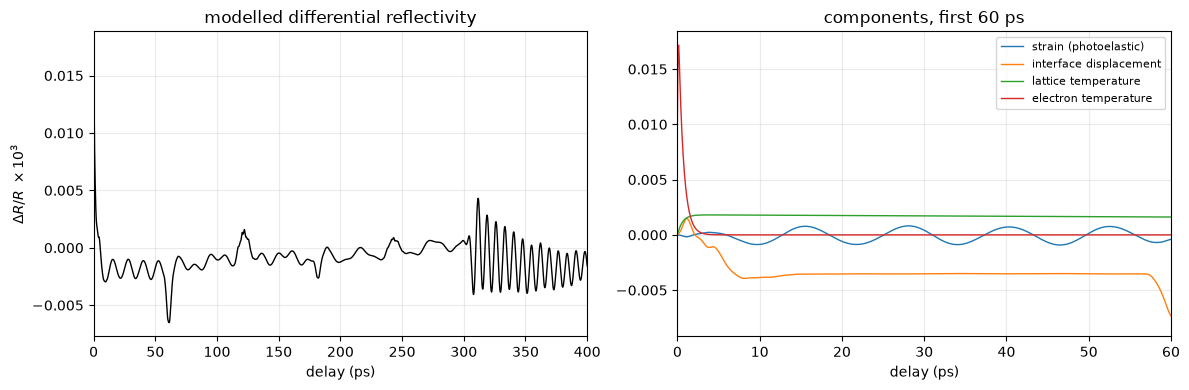

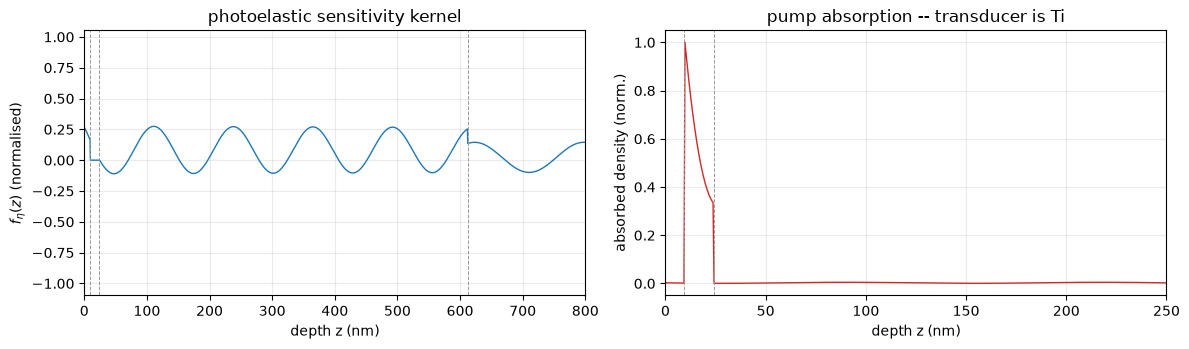

In [16]:
res = run_model(cfg=dict(dz_nm=0.5, t_max_ps=400.0, save_strain=True))
print("written:", save_result(res, r"C:\Users\ramesh\Projects_TOPTEC\Generated_data\diffR_signal_thinfilm_model_custom", save_strain_map=True))
plot_result(res, zoom_ps=60)
plot_kernels(res)
plt.show()


# 13. Build a custom sample and run it

In [17]:
thicknesses = [100, 200, 300, 400, 500, 588]   # nm, Si3N4 layer

results = {}
for d in thicknesses:
    layers = [
        ("Ti", 15.00),
        ("Si3N4", 9.44),
        ("Ti",    14.37),
        ("Si3N4", d),        # vary this
        ("SiO2",  1454.0),
        ("Si",    None),
    ]
    stack, materials = build_sample(layers, LIB, CFG, verbose=False)
    res = run_model(stack=stack, materials=materials, cfg=CFG, verbose=False)
    results[d] = res

# Plot all together
fig, ax = plt.subplots(figsize=(10, 5))
for d, res in results.items():
    ax.plot(res["t_ps"], res["drr"] * 1e3, label=f"Si3N4 = {d} nm")
ax.set_xlabel("delay (ps)")
ax.set_ylabel("dR/R × 10³")
ax.legend()
plt.show()

MissingMaterialData: 
Missing material data -- nothing was substituted.

  layer 4:SiO2:
      optical file   no SiO2.txt in L:\Compressed sensing\Matlab\ultrafast_Spectroscopy\fs_sonar\diffR_model\materials

These have no literature entry either, so you must supply them:

fill = {
    "SiO2": dict(),
}

then  build_sample(SAMPLE, LIB, CFG, fill=fill).

A missing dispersion file cannot be patched through fill=; add the .txt to the
materials folder, or give n_pump and n_probe as a per-layer override:
    ("HfO2", 50.0, dict(n_pump=2.1+0j, n_probe=2.08+0j))